### PSA Dataset

In [1]:
import json
import numpy as np
import pandas as pd
import os
import re

In [25]:
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca.json', 'r') as f:
    data_old = json.load(f)
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated.json', 'r') as f:
    data_new = json.load(f)


In [14]:
data_new_new = {}
train_list = []
for i in data_old['train']:
    temp_dict = {}
    temp_dict['image'] = i['image']
    temp_dict['label'] = i['label']
    temp_dict['mask'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/prostate_mask', i['image'])
    temp_dict['dwi'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/DWI_registered', i['image'])
    temp_dict['adc'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/ADC_clipped', i['image'])
    temp_dict['heatmap'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/heatmaps', i['image'])
    temp_dict['smooth_mask'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/smooth_prostate_mask', i['image'])
    train_list.append(temp_dict)
for i in data_old['test']:
    temp_dict = {}
    temp_dict['image'] = i['image']
    temp_dict['label'] = i['label']
    temp_dict['mask'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/prostate_mask', i['image'])
    temp_dict['dwi'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/DWI_registered', i['image'])
    temp_dict['adc'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/ADC_clipped', i['image'])
    temp_dict['heatmap'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/heatmaps', i['image'])
    temp_dict['smooth_mask'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/smooth_prostate_mask', i['image'])
    train_list.append(temp_dict)
    

In [15]:
data_new_new['test'] = train_list
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated_test.json', 'w') as f:
    json.dump(data_new_new, f, indent = 4)

In [27]:
data_new

{'train': [{'image': '10101_1000101.nrrd',
   'mask': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/prostate_mask/10101_1000101.nrrd',
   'dwi': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/DWI_registered/10101_1000101.nrrd',
   'adc': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/ADC_clipped/10101_1000101.nrrd',
   'heatmap': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/heatmaps/10101_1000101.nrrd',
   'label': 0,
   'smooth_mask': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/smooth_prostate_mask/10101_1000101.nrrd'},
  {'image': '10890_1000906.nrrd',
   'mask': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/prostate_mask/10890_1000906.nrrd',
   'dwi': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/DWI_registered/10890_1000906.nrrd',
   'adc': '/sc-projects/sc-proj-cc06-

In [5]:
print(len(data_old['train']))
print(len(data_old['test']))
print(len(data_new['train']))
print(len(data_new['test']))

680
170
644
162


### PSA

In [39]:
data = pd.read_csv(
    "/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/marksheet.csv"

)
print(data.shape)
data.head()

(1500, 13)


,patient_id,study_id,mri_date,patient_age,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa,center
0,10000,1000000,2019-07-02,73,7.7,NaN,55.0,MRBx,0+0,0,0,NO,PCNN
1,10001,1000001,2016-05-27,64,8.7,0.09,102.0,NaN,NaN,NaN,0,NO,RUMC
2,10002,1000002,2021-04-18,58,4.2,0.06,74.0,NaN,NaN,NaN,0,NO,ZGT
3,10003,1000003,2019-04-05,72,13.0,NaN,71.5,SysBx,0+0,0,0,NO,ZGT
4,10004,1000004,2020-10-21,67,8.0,0.10,78.0,SysBx+MRBx,"0+0,0+0","0,0",0,NO,RUMC


In [40]:
cleaned_data = data.dropna(subset=['psa', 'prostate_volume'])
cleaned_data.shape

(1439, 13)

In [41]:
data_new = {}
test_list = []
for i in cleaned_data.iloc:
    temp_dict = {}
    img_name = str(i.patient_id)+'_'+str(i.study_id)+'.nrrd'
    temp_dict['image'] = img_name
    label_ = 5
    if i.case_csPCa == 'YES':
        label_ = 1
    elif i.case_csPCa == 'NO':
        label_ = 0 
    temp_dict['label'] = label_
    temp_dict['mask'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/prostate_mask', img_name)
    temp_dict['dwi'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/DWI_registered', img_name)
    temp_dict['adc'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/ADC_clipped', img_name)
    temp_dict['heatmap'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/heatmaps', img_name)
    temp_dict['smooth_mask'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/smooth_prostate_mask', img_name)
    test_list.append(temp_dict)

In [44]:
print(len(test_list))

1439


In [43]:
data_new['test'] = test_list
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated_test_full.json', 'w') as f:
    json.dump(data_new, f, indent = 4)

In [45]:
with open(
    "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated_test_full.json",
) as f:
    json_data = json.load(f)
'''
new_train = []
for i in json_data["train"]:
    p_id = i["image"].split("_")[0]
    st_id = i["image"].split("_")[1].split(".")[0]
    row = data[(data["patient_id"] == int(p_id)) & (data["study_id"] == int(st_id))]
    pvol = row["prostate_volume"].iloc[0]
    psa = row["psa"].iloc[0]
    if pd.notna(psa) and psa != "" and pd.notna(pvol) and pvol != "":
        i["psa"] = [psa, pvol]
        new_train.append(i)

print(len(new_train))
print(len(json_data["train"]))
'''
lab_count =[]
new_test = []
for i in json_data["test"]:
    p_id = i["image"].split("_")[0]
    st_id = i["image"].split("_")[1].split(".")[0]
    row = data[(data["patient_id"] == int(p_id)) & (data["study_id"] == int(st_id))]
    pvol = row["prostate_volume"].iloc[0]
    psa = row["psa"].iloc[0]
    if pd.notna(psa) and psa != "" and pd.notna(pvol) and pvol != "":
        i["psa"] = [psa, pvol]
        new_test.append(i)
        lab_count.append(i["label"])
print(len(new_test))
print(len(json_data["test"]))

#json_data["train"] = new_train
json_data["test"] = new_test
with open(
    "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated_test_full_with_psa.json",
    "w",
) as f:
    json.dump(json_data, f, indent=4)

1439
1439


### Test data

In [ ]:
test_df = pd.read_excel(
    "/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/anon_data.xlsx"
)
test_df.head()

In [ ]:
row

In [ ]:
with open(
    "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/test_data_updated.json",
) as f:
    json_data = json.load(f)


new_test = []
for i in json_data["test"]:
    p_id = i["image"].split(".")[0]

    row = test_df[(test_df["PATIENT_ID"] == int(p_id))]

    pvol = row["PROSTATE_VOLUME"].iloc[0]
    psa = row["PSA"].iloc[0]
    if pd.notna(psa) and psa != "" and pd.notna(pvol) and pvol != "":
        i["psa"] = [float(psa), float(pvol)]
        new_test.append(i)

print(len(new_test))
print(len(json_data["test"]))


json_data["test"] = new_test
with open(
    "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/test_data_updated_with_psa.json",
    "w",
) as f:
    json.dump(json_data, f, indent=4)

In [ ]:
import numpy as np

### Normalize PSA and PSAD

In [ ]:
import sys
from pathlib import Path

import torch
import yaml

from src.data.data_loader import get_dataloader

# from src.model.cspca_model import CSPCAModel
from src.model.mil import MILModel3D

with open(
    "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/config/config_cspca_train.yaml",
) as f:
    cfg = yaml.safe_load(f)
from argparse import Namespace

args = Namespace(**cfg)

In [ ]:
args.mode = "train"
args.project_dir = (
    "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/"
)
args.checkpoint_cspca = None

args.run_name = "check_dummy"

args.logdir = os.path.join(args.project_dir, "logs", args.run_name)
os.makedirs(args.logdir, exist_ok=True)


if args.dataset_json is None:
    print("Dataset path not provided. Quitting.")
    sys.exit(1)
if args.checkpoint_pirads is None and args.mode == "train":
    print("PI-RADS checkpoint path not provided. Quitting.")
    sys.exit(1)
elif args.checkpoint_cspca is None and args.mode == "test":
    print("csPCa checkpoint path not provided. Quitting.")
    sys.exit(1)

args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if args.device == torch.device("cuda"):
    torch.backends.cudnn.benchmark = True

In [ ]:
import json

from sklearn.preprocessing import StandardScaler

args.num_classes = 4
args.mil_mode = "att_trans"
mil_model = MILModel3D(num_classes=args.num_classes, mil_mode=args.mil_mode)
cache_dir_path = Path(os.path.join(args.logdir, "cache"))

scaler = StandardScaler()
with open(os.path.join(args.project_dir, "dataset", "PICAI_cspca_updated_with_psa.json")) as f:
    dataset_json = json.load(f)
train_clinical = [i["psa"] for i in dataset_json["train"]]
_ = scaler.fit_transform(train_clinical)
args.psa_mean = scaler.mean_.tolist()
args.psa_std = scaler.scale_.tolist()

In [ ]:
from __future__ import annotations

import torch
import torch.nn as nn
from monai.utils.module import optional_import

models, _ = optional_import("torchvision.models")


class SimpleNN(nn.Module):
    """
    A simple Multi-Layer Perceptron (MLP) for binary classification.

    This network consists of two hidden layers with ReLU activation and a dropout layer,
    followed by a final sigmoid activation for probability output.

    Args:
        input_dim (int): The number of input features.
    """

    def __init__(self, input_dim: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 1),
            nn.Sigmoid(),  # since binary classification
        )

    def forward(self, x):
        """
        Forward pass of the classifier.

        Args:
            x (torch.Tensor): Input tensor of shape (Batch, input_dim).

        Returns:
            torch.Tensor: Output probabilities of shape (Batch, 1).
        """
        return self.net(x)


class CSPCAModel(nn.Module):
    """
    Clinically Significant Prostate Cancer (csPCa) risk prediction model using a MIL backbone.

    This model repurposes a pre-trained Multiple Instance Learning (MIL) backbone (originally
    designed for PI-RADS prediction) for binary csPCa risk assessment. It utilizes the
    backbone's feature extractor, transformer, and attention mechanism to aggregate instance-level
    features into a bag-level embedding.

    The original fully connected classification head of the backbone is replaced by a
    custom :class:`SimpleNN` head for the new task.

    Args:
        backbone (nn.Module): A pre-trained MIL model. The backbone must possess the
            following attributes/sub-modules:
            - ``net``: The CNN feature extractor.
            - ``transformer``: A sequence modeling module.
            - ``attention``: An attention mechanism for pooling.
            - ``myfc``: The original fully connected layer (used to determine feature dimensions).

    Attributes:
        fc_cspca (SimpleNN): The new classification head for csPCa prediction.
        backbone: The MIL based PI-RADS classifier.
    """

    def __init__(self, backbone: nn.Module) -> None:
        super().__init__()
        self.backbone = backbone

        self.clinical_dim = 2
        self.projection_dim = 16
        self.clinical_projection = nn.Sequential(
            nn.Linear(self.clinical_dim, self.projection_dim),
            nn.ReLU(),
            nn.BatchNorm1d(self.projection_dim),  # Helps stabilize the merged scale
        )

        self.fc_dim = backbone.myfc.in_features
        self.fc_cspca = SimpleNN(input_dim=self.fc_dim + self.projection_dim)

    def forward(self, x, psa_data):
        sh = x.shape
        x = x.reshape(sh[0] * sh[1], sh[2], sh[3], sh[4], sh[5])
        x = self.backbone.net(x)
        x = x.reshape(sh[0], sh[1], -1)
        x = x.permute(1, 0, 2)
        x = self.backbone.transformer(x)
        x = x.permute(1, 0, 2)
        a = self.backbone.attention(x)
        a = torch.softmax(a, dim=1)
        x = torch.sum(x * a, dim=1)

        psa_features = self.clinical_projection(psa_data)
        x = torch.cat((x, psa_features), dim=1)

        x = self.fc_cspca(x)
        return x

In [ ]:
args.use_psa = True
checkpoint = torch.load(args.checkpoint_pirads, weights_only=False, map_location="cpu")
mil_model.load_state_dict(checkpoint["state_dict"])
mil_model = mil_model.to(args.device)
train_loader = get_dataloader(args, split="train")
valid_loader = get_dataloader(args, split="test")
cspca_model = CSPCAModel(backbone=mil_model).to(args.device)

In [ ]:
for submodule in [
    cspca_model.backbone.net,
    cspca_model.backbone.myfc,
    cspca_model.backbone.transformer,
]:
    for param in submodule.parameters():
        param.requires_grad = False

args.optim_lr = 1e-4
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cspca_model.parameters()), lr=args.optim_lr
)

In [ ]:
import torch
import torch.nn as nn
from monai.metrics import Cumulative, CumulativeAverage

old_loss = float("inf")
epoch = 0
cspca_model.train()
criterion = nn.BCELoss()
loss = 0.0
run_loss = CumulativeAverage()
targets_cumulative = Cumulative()
preds_cumulative = Cumulative()

In [ ]:
for _, batch_data in enumerate(train_loader):
    data = batch_data["image"].as_subclass(torch.Tensor).to(args.device)
    target = batch_data["label"].as_subclass(torch.Tensor).to(args.device)
    psa_data = batch_data["psa"].as_subclass(torch.Tensor).to(args.device)
    break

In [ ]:
optimizer.zero_grad()
output = cspca_model(data, psa_data)
output = output.squeeze(1)
loss = criterion(output, target)
loss.backward()
optimizer.step()

targets_cumulative.extend(target.detach().cpu())
preds_cumulative.extend(output.detach().cpu())
run_loss.append(loss.item())

### Visualise Logs

In [1]:
import re

train_loss_dict = {}
val_loss_dict = {}
train_auc_dict = {}
val_auc_dict = {}

In [2]:
with open(
    "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/logs/cspca_finetune/cspca_finetune.log",
) as f:
    for line in f:
        m = re.search(
            r"EPOCH (\d+) TRAIN loss: ([0-9.]+) TRAIN ATTN LOSS: ([0-9.]+) TRAIN AUC: ([0-9.]+)",
            line,
        )
        if m:
            e = int(m.group(1))
            train_loss_dict[e] = float(m.group(2))
            # train_attn_loss_dict[e] = float(m.group(3))
            train_auc_dict[e] = float(m.group(4))

        m = re.search(
            r"EPOCH (\d+) VAL loss: ([0-9.]+) AUC: ([0-9.]+)",
            line,
        )
        if m:
            e = int(m.group(1))
            val_loss_dict[e] = float(m.group(2))
            val_auc_dict[e] = float(m.group(3))

In [ ]:
with open(
    "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/logs/cspca_train_randmodel_newtrain/cspca_train_randmodel_newtrain.log",
) as f:
    for line in f:
        m = re.search(r"EPOCH (\d+) TRAIN loss: ([0-9.]+) AUC: ([0-9.]+)", line)
        if m:
            e = int(m.group(1))
            train_loss_dict[e] = float(m.group(2))
            train_auc_dict[e] = float(m.group(3))

        m = re.search(r"EPOCH (\d+) VAL loss: ([0-9.]+) AUC: ([0-9.]+)", line)
        if m:
            e = int(m.group(1))
            val_loss_dict[e] = float(m.group(2))
            val_auc_dict[e] = float(m.group(3))

In [4]:
val_loss_dict[5] = 0.5616
val_auc_dict[5] = 0.6906

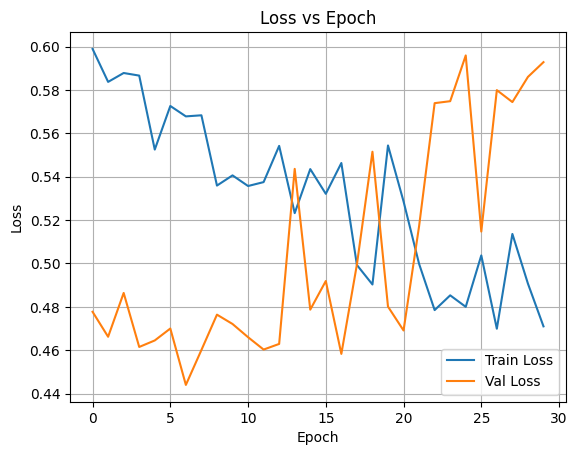

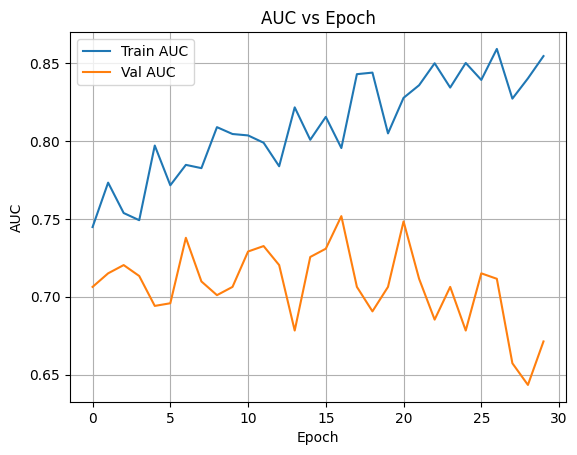

In [3]:
epochs = sorted(train_loss_dict.keys())

train_loss = [train_loss_dict[e] for e in epochs]
val_loss = [val_loss_dict[e] for e in epochs]
train_auc = [train_auc_dict[e] for e in epochs]
val_auc = [val_auc_dict[e] for e in epochs]

import matplotlib.pyplot as plt

# --- Loss ---
plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid()
plt.show()

# --- AUC ---
plt.figure()
plt.plot(epochs, train_auc, label="Train AUC")
plt.plot(epochs, val_auc, label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("AUC vs Epoch")
plt.legend()
plt.grid()
plt.show()

### Check transformation

In [ ]:
import json
import os

import numpy as np
from AIAH_utility.viewer import BasicViewer
from monai.transforms import Compose, LoadImaged, RandRotate90d

In [ ]:
with open(
    "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PI-RADS_data_updated.json",
) as f:
    data = json.load(f)
train_data = data["train"]
t2_dir = "/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/t2_registered"

In [2]:
from monai.networks.nets import resnet

In [5]:
net = resnet.resnet50(
    spatial_dims=3,
    n_input_channels=1,
    num_classes=5,
    norm=("group", {"num_groups": 8}),
    pretrained=True,
)

NotImplementedError: Please set n_input_channels to 1and feed_forward to False in order to use MedicalNet pretrained weights

In [ ]:
og_transforms = Compose(
    [
        # 1. Flip Left-Right (Axis 0) - Very safe, medically common
        LoadImaged(
            keys=["image"],
            reader="ITKReader",
            ensure_channel_first=True,
            dtype=np.float32,
        ),
        # RandFlipd(keys=["image"], spatial_axis=0, prob=0.5),
        # RandRotate90d(keys=["image"], spatial_axes=(0, 1), prob=0.5),
    ]
)
rand_transforms = Compose(
    [
        # 1. Flip Left-Right (Axis 0) - Very safe, medically common
        LoadImaged(
            keys=["image"],
            reader="ITKReader",
            ensure_channel_first=True,
            dtype=np.float32,
        ),
        # RandFlipd(keys=["image"], spatial_axis=0, prob=0.9),
        RandRotate90d(keys=["image"], spatial_axes=(0, 1), prob=0.9),
    ]
)

In [ ]:
og = og_transforms({"image": os.path.join(t2_dir, train_data[0]["image"])})
rand = rand_transforms({"image": os.path.join(t2_dir, train_data[0]["image"])})
BasicViewer(og["image"][0]).show()

In [ ]:
BasicViewer(rand["image"][0]).show()

In [ ]:
import json
import os

import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/marksheet.csv")
with open(
    "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated_with_psa.json",
) as f:
    json_data = json.load(f)
df.head()

In [ ]:
i = json_data["train"][9]
print(i["label"])
p_id = i["image"].split("_")[0]
st_id = i["image"].split("_")[1].split(".")[0]
row = df[(df["patient_id"] == int(p_id)) & (df["study_id"] == int(st_id))]
row

In [ ]:
import os

import numpy as np
import torch
from monai.data import load_decathlon_datalist
from monai.transforms import (
    Compose,
    ConcatItemsd,
    LoadImaged,
    RandRotate90d,
)
from sklearn.preprocessing import StandardScaler

from src.data.custom_transforms import (
    ClipMaskIntensityPercentilesd,
    ElementwiseProductd,
    NormalizeIntensity_customd,
)

In [ ]:
transform = Compose(
    [
        LoadImaged(
            keys=["image", "mask", "dwi", "adc", "heatmap", "smooth_mask"],
            reader="ITKReader",
            ensure_channel_first=True,
            dtype=np.float32,
        ),
        ClipMaskIntensityPercentilesd(keys=["image"], lower=0, upper=99.5, mask_key="mask"),
        ClipMaskIntensityPercentilesd(keys=["dwi"], lower=0, upper=99.5, mask_key="mask"),
        NormalizeIntensity_customd(keys=["image"], mask_key="mask"),
        NormalizeIntensity_customd(keys=["dwi"], mask_key="mask"),
        ConcatItemsd(keys=["image", "dwi", "adc"], name="image", dim=0),  # stacks to (3, H, W)
        ElementwiseProductd(keys=["heatmap", "smooth_mask"], output_key="final_heatmap"),
        RandRotate90d(
            keys=["image", "final_heatmap", "smooth_mask"], prob=0.9, spatial_axes=(1, 2), max_k=3
        ),
    ]
)

In [ ]:
data_list = load_decathlon_datalist(
    data_list_file_path="/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PI-RADS_data_updated.json",
    data_list_key="test",
    base_dir="/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/t2_registered",
)

In [ ]:
data_list[0]

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
a = transform(data_list[0])

In [ ]:
a["image"].shape

In [ ]:
plt.imshow(a["image"][0, :, :, 10])

In [ ]:
plt.imshow(a["image"][0, :, :, 10])

In [ ]:
plt.imshow(a["image"][0, :, :, 11])

In [ ]:
plt.imshow(a["image"][0, :, :, 11])

In [ ]:
plt.imshow(a["image"][0, :, :, 12])